<a href="https://colab.research.google.com/github/januarsyah901/halal-food-classifier/blob/main/halal_haram_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Klasifikasi Kehalalan Bahan Makanan Menggunakan Machine Learning dan Deep Learning

Notebook ini dibuat untuk melakukan klasifikasi kehalalan bahan makanan berdasarkan daftar komposisi (*ingredient list*) menggunakan dataset `cleaned_dataset.csv`.

Kita akan menggunakan dua pendekatan:
1. **Klasikal Machine Learning (Baseline)**: TF-IDF Vectorizer + Logistic Regression.
2. **Deep Learning (State-of-the-Art NLP)**: Fine-Tuning pretrained Transformer Model (**DistilBERT**).

## Persiapan di Google Colab:
1. Pastikan Anda mengaktifkan **GPU** di Colab: `Runtime` -> `Change runtime type` -> Pilih **T4 GPU** (atau GPU yang tersedia).
2. Upload file `cleaned_dataset.csv` ke direktori Colab Anda dengan klik ikon folder di sebelah kiri dan klik tombol upload.

## 1. Install & Import Library yang Dibutuhkan

In [ ]:
# Install library Hugging Face Transformers dan Accelerate untuk training Deep Learning
!pip install -q transformers datasets accelerate scikit-learn pandas numpy matplotlib seaborn

In [ ]:
!pip install -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 67.1 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import time
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# Set style untuk visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load & Explore Dataset

Kita akan membaca file `cleaned_dataset.csv`, melihat bentuk datanya, mendeteksi nilai kosong/duplikat, serta melihat distribusi kelas **Halal** dan **Haram**.

In [ ]:
# Load dataset
try:
    df = pd.read_csv('https://raw.githubusercontent.com/januarsyah901/halal-food-classifier/ca65da057adaabb91ec01a254fd0ba82918b7992/cleaned_dataset.csv')
    print("Dataset berhasil dimuat!")
except FileNotFoundError:
    print("""File cleaned_dataset.csv tidak ditemukan!
Silakan upload file tersebut ke Colab terlebih dahulu.
Atau pastikan URL yang digunakan adalah URL raw file di GitHub.""")

# Tampilkan 5 baris pertama
df.head()

Dataset berhasil dimuat!


,text,label
0,vegetable oil,halal
1,beef stock contains less than of mirepoix carr...,halal
2,clam stock potatoes clams cream vegetable oil ...,haram
3,water cream broccoli celery vegetable oil corn...,haram
4,chicken stock contains less than of yeast extr...,halal


In [ ]:
# Informasi dasar dataset
print("=== Dataset Info ===")
print(df.info())
print(f"\nJumlah data awal: {len(df)} baris")

# Cek data kosong (missing values)
print("\nJumlah data kosong per kolom:")
print(df.isnull().sum())

# Hapus data yang kosong pada kolom text atau label jika ada
df = df.dropna(subset=['text', 'label'])

# Bersihkan text dari spasi berlebih dan ubah ke lowercase
df['text'] = df['text'].str.lower().str.strip()

# Cek distribusi kelas halal vs haram
class_counts = df['label'].value_counts()
print("\nDistribusi Label Kehalalan:")
print(class_counts)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39787 entries, 0 to 39786
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    39787 non-null  object
 1   label   39787 non-null  object
dtypes: object(2)
memory usage: 621.8+ KB
None

Jumlah data awal: 39787 baris

Jumlah data kosong per kolom:
text     0
label    0
dtype: int64

Distribusi Label Kehalalan:
label
halal    21826
haram    17961
Name: count, dtype: int64


/tmp/ipykernel_496/2266824863.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette=["#2ecc71", "#e74c3c"])


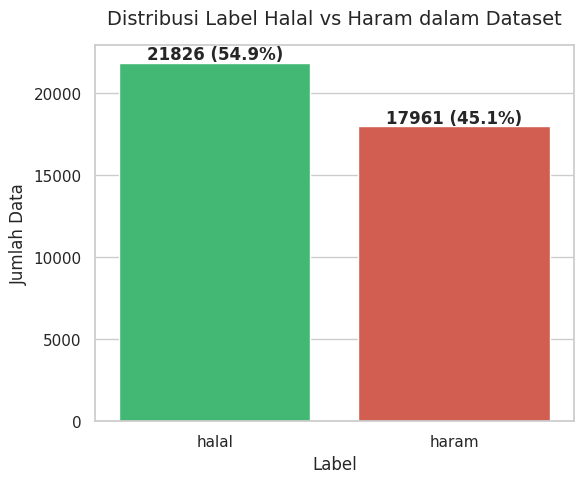

In [ ]:
# Visualisasi Distribusi Kelas
plt.figure(figsize=(6, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette=["#2ecc71", "#e74c3c"])
plt.title("Distribusi Label Halal vs Haram dalam Dataset", fontsize=14, pad=15)
plt.xlabel("Label", fontsize=12)
plt.ylabel("Jumlah Data", fontsize=12)
for i, val in enumerate(class_counts.values):
    plt.text(i, val + 200, f"{val} ({val/len(df)*100:.1f}%)", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Data Splitting & Label Encoding

Kita membagi dataset menjadi data training dan data testing dengan rasio **80:20**.
Kita juga menyamakan label string (`halal` & `haram`) menjadi numerik (`0` & `1`) agar bisa diproses oleh model.

In [ ]:
# Bagi dataset menjadi 80% Train dan 20% Test secara stratify (menjaga rasio label)
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

# Encode label ke dalam bentuk numerik
# halal -> 0, haram -> 1
label_map = {'halal': 0, 'haram': 1}
y_train_encoded = y_train.map(label_map)
y_test_encoded = y_test.map(label_map)

print(f"Ukuran Data Training: {len(X_train)} baris")
print(f"Ukuran Data Testing: {len(X_test)} baris")

Ukuran Data Training: 31829 baris
Ukuran Data Testing: 7958 baris


## 4. Pendekatan 1: Klasikal Machine Learning (TF-IDF + Logistic Regression)

Ini adalah model baseline yang sangat cepat, efisien, dan memiliki interpretasi tinggi.
- **TF-IDF Vectorizer**: Mengubah teks komposisi menjadi representasi matriks angka berdasarkan frekuensi kata.
- **Logistic Regression**: Melakukan klasifikasi linear yang sangat kuat untuk teks dengan fitur sparse.

In [ ]:
# Ekstraksi fitur menggunakan TF-IDF (n-gram dari 1 sampai 2 kata)
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

print("Mengekstrak fitur teks menggunakan TF-IDF...")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print(f"Dimensi data TF-IDF: {X_train_tfidf.shape}")

# Inisialisasi dan latih Logistic Regression
print("Training model Logistic Regression...")
start_time = time.time()
lr_model = LogisticRegression(max_iter=1000, C=1.0)
lr_model.fit(X_train_tfidf, y_train_encoded)
lr_time = time.time() - start_time
print(f"Training selesai dalam {lr_time:.2f} detik!")

Mengekstrak fitur teks menggunakan TF-IDF...
Dimensi data TF-IDF: (31829, 10000)
Training model Logistic Regression...
Training selesai dalam 0.49 detik!


In [ ]:
# Evaluasi model Logistic Regression
y_pred_lr = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test_encoded, y_pred_lr)
lr_f1 = f1_score(y_test_encoded, y_pred_lr)

print("\n=== EVALUASI LOGISTIC REGRESSION ===")
print(f"Accuracy: {lr_acc*100:.2f}%")
print(f"F1-Score: {lr_f1*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_lr, target_names=['halal', 'haram']))


=== EVALUASI LOGISTIC REGRESSION ===
Accuracy: 96.87%
F1-Score: 96.45%

Classification Report:
              precision    recall  f1-score   support

       halal       0.95      0.99      0.97      4366
       haram       0.99      0.94      0.96      3592

    accuracy                           0.97      7958
   macro avg       0.97      0.97      0.97      7958
weighted avg       0.97      0.97      0.97      7958



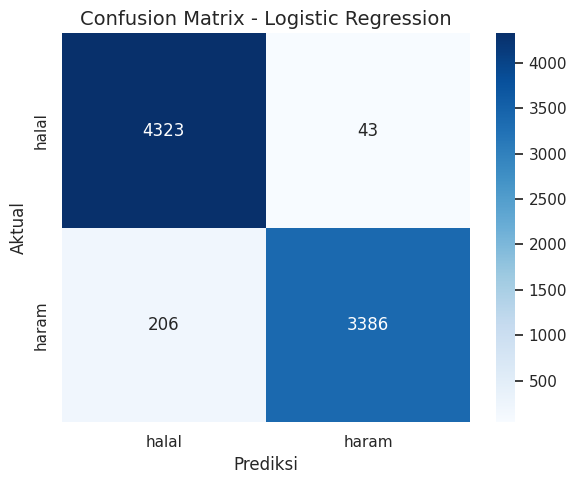

In [ ]:
# Plot Confusion Matrix untuk Logistic Regression
cm_lr = confusion_matrix(y_test_encoded, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['halal', 'haram'], yticklabels=['halal', 'haram'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Aktual', fontsize=12)
plt.tight_layout()
plt.show()

### Analisis Fitur Penting (Feature Importance)

Kelebihan dari Logistic Regression adalah kita bisa melihat kata/komposisi apa saja yang paling memengaruhi keputusan model menjadi **HALAL** maupun **HARAM** berdasarkan nilai koefisiennya.

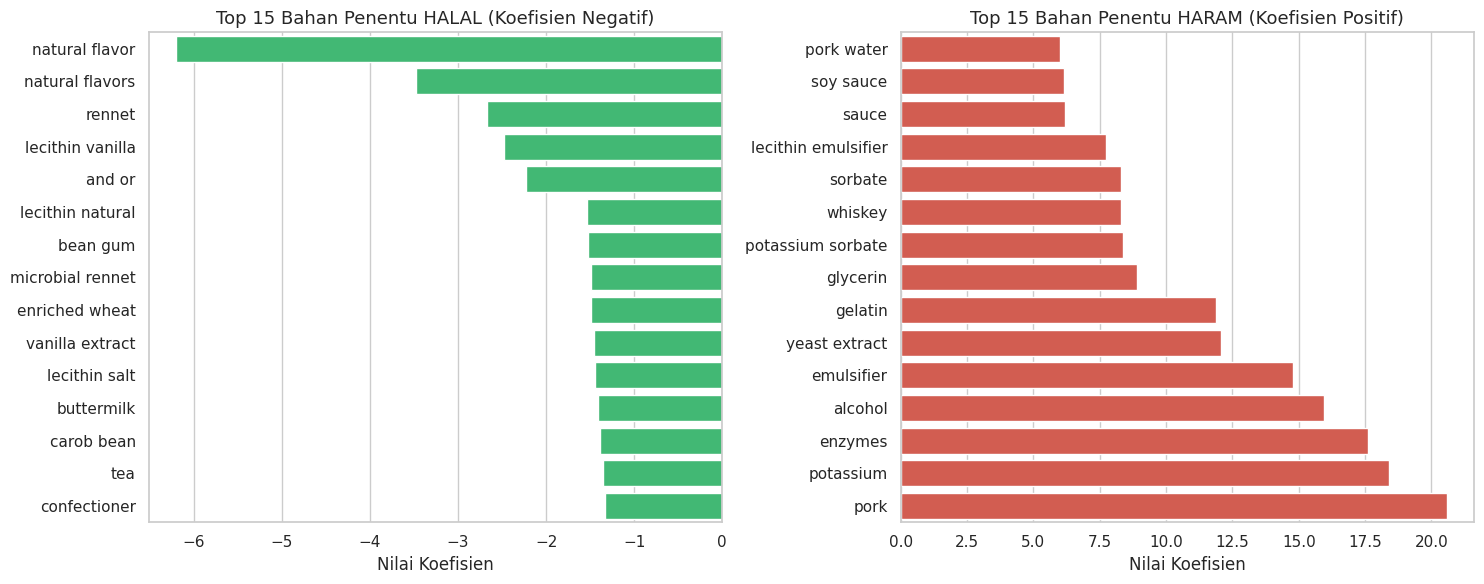

In [ ]:
feature_names = np.array(vectorizer.get_feature_names_out())
coef = lr_model.coef_[0]

# Ambil top 15 kata dengan bobot penentu haram (koefisien positif tertinggi)
# dan halal (koefisien negatif terendah)
top_haram_idx = np.argsort(coef)[-15:]
top_halal_idx = np.argsort(coef)[:15]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Halal Penentu
sns.barplot(
    x=coef[top_halal_idx],
    y=feature_names[top_halal_idx],
    ax=axes[0],
    color='#2ecc71'
)
axes[0].set_title("Top 15 Bahan Penentu HALAL (Koefisien Negatif)", fontsize=13)
axes[0].set_xlabel("Nilai Koefisien")

# Plot Haram Penentu
sns.barplot(
    x=coef[top_haram_idx],
    y=feature_names[top_haram_idx],
    ax=axes[1],
    color='#e74c3c'
)
axes[1].set_title("Top 15 Bahan Penentu HARAM (Koefisien Positif)", fontsize=13)
axes[1].set_xlabel("Nilai Koefisien")

plt.tight_layout()
plt.show()

## 5. Pendekatan 2: Deep Learning (Fine-Tuning DistilBERT)

Kita akan menggunakan **DistilBERT**, sebuah versi BERT yang lebih ringan (40% lebih kecil, 60% lebih cepat) tetapi mempertahankan 97% kemampuan pemahaman bahasa BERT.
Ini akan membantu model memahami urutan kata, konteks, dan pola kompleks di dalam komposisi bahan makanan.

In [ ]:
# Pastikan GPU aktif
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan device: {device}")
if device.type != 'cuda':
    print("WARNING: GPU tidak aktif. Proses fine-tuning mungkin akan berjalan sangat lambat. Silakan aktifkan T4 GPU di menu Runtime.")

Menggunakan device: cuda


In [ ]:
# Buat data split khusus untuk Deep Learning (Train, Validation, Test)
train_df = pd.DataFrame({'text': X_train, 'label': y_train_encoded})
test_df = pd.DataFrame({'text': X_test, 'label': y_test_encoded})

# Pisahkan 10% data Train menjadi Validation untuk memantau overfitting saat training
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df['label'])

# Konversi ke objek Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
# Load Pre-trained Tokenizer DistilBERT
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Fungsi Tokenisasi teks
def tokenize_fn(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

print("Melakukan tokenisasi teks pada dataset...")
train_tokenized = train_dataset.map(tokenize_fn, batched=True)
val_tokenized = val_dataset.map(tokenize_fn, batched=True)
test_tokenized = test_dataset.map(tokenize_fn, batched=True)

# Hapus kolom teks asli agar menyisakan tensor input untuk model
train_tokenized = train_tokenized.remove_columns(['text', '__index_level_0__'])
val_tokenized = val_tokenized.remove_columns(['text', '__index_level_0__'])
test_tokenized = test_tokenized.remove_columns(['text'])

# Set format ke PyTorch Tensors
train_tokenized.set_format('torch')
val_tokenized.set_format('torch')
test_tokenized.set_format('torch')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Melakukan tokenisasi teks pada dataset...


Map:   0%|          | 0/28646 [00:00<?, ? examples/s]

Map:   0%|          | 0/3183 [00:00<?, ? examples/s]

Map:   0%|          | 0/7958 [00:00<?, ? examples/s]

In [ ]:
# Load Pre-trained Model DistilBERT untuk Klasifikasi Sekuensial (2 kelas: Halal & Haram)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.to(device)

# Definisikan parameter training
training_args = TrainingArguments(
    output_dir='./results_distilbert',
    num_train_epochs=2,                  # 2 epoch saja sudah sangat baik untuk transformer di dataset sebesar ini
    per_device_train_batch_size=32,      # Ukuran batch training
    per_device_eval_batch_size=32,       # Ukuran batch evaluasi
    eval_strategy='epoch',         # Evaluasi di setiap akhir epoch
    save_strategy='epoch',               # Simpan model checkpoint setiap epoch
    learning_rate=2e-5,                  # Learning rate kecil khas finetuning BERT
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    load_best_model_at_end=True,         # Ambil bobot model terbaik berdasarkan evaluasi loss
    metric_for_best_model='eval_loss',
    fp16=True,                           # Aktifkan mixed precision (training 2x lebih cepat pada T4 GPU)
    report_to='none'                     # Menonaktifkan logging ke wandb/tensorboard luar
)

# Fungsi untuk menghitung metrik evaluasi
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    return {'accuracy': acc, 'f1': f1}

# Buat objek Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics
)

# Jalankan Fine-Tuning!
print("Memulai Fine-Tuning DistilBERT pada GPU...")
start_time = time.time()
trainer.train()
dl_time = time.time() - start_time
print(f"Fine-Tuning selesai dalam {dl_time/60:.2f} menit!")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Memulai Fine-Tuning DistilBERT pada GPU...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.058163,0.080798,0.979893,0.977916
2,0.042598,0.047836,0.987747,0.986378


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-Tuning selesai dalam 3.21 menit!


In [ ]:
# Lakukan evaluasi pada data test independen
print("Menguji model DistilBERT pada data test...")
test_predictions = trainer.predict(test_tokenized)
y_pred_dl = np.argmax(test_predictions.predictions, axis=-1)

dl_acc = accuracy_score(y_test_encoded, y_pred_dl)
dl_f1 = f1_score(y_test_encoded, y_pred_dl)

print("\n=== EVALUASI DEEP LEARNING (DISTILBERT) ===")
print(f"Accuracy: {dl_acc*100:.2f}%")
print(f"F1-Score: {dl_f1*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_dl, target_names=['halal', 'haram']))

Menguji model DistilBERT pada data test...



=== EVALUASI DEEP LEARNING (DISTILBERT) ===
Accuracy: 98.99%
F1-Score: 98.88%

Classification Report:
              precision    recall  f1-score   support

       halal       0.99      0.99      0.99      4366
       haram       0.99      0.99      0.99      3592

    accuracy                           0.99      7958
   macro avg       0.99      0.99      0.99      7958
weighted avg       0.99      0.99      0.99      7958



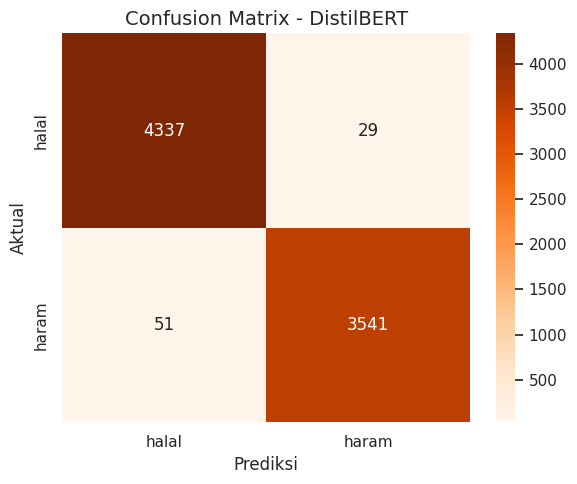

In [ ]:
# Plot Confusion Matrix untuk DistilBERT
cm_dl = confusion_matrix(y_test_encoded, y_pred_dl)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['halal', 'haram'], yticklabels=['halal', 'haram'])
plt.title('Confusion Matrix - DistilBERT', fontsize=14)
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Aktual', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Perbandingan Performa Model

Mari kita bandingkan secara visual akurasi, f1-score, dan waktu training antara **Logistic Regression** dan **DistilBERT**.

=== Perbandingan Metrik ===
                     Model  Accuracy (%)  F1-Score (%)  Training Time (Detik)
  Logistic Regression (ML)     96.871073     96.453497               0.489265
DistilBERT (Deep Learning)     98.994722     98.882994             192.379562


/tmp/ipykernel_496/341282596.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Model', y='Accuracy (%)', palette=['#3498db', '#e67e22'])


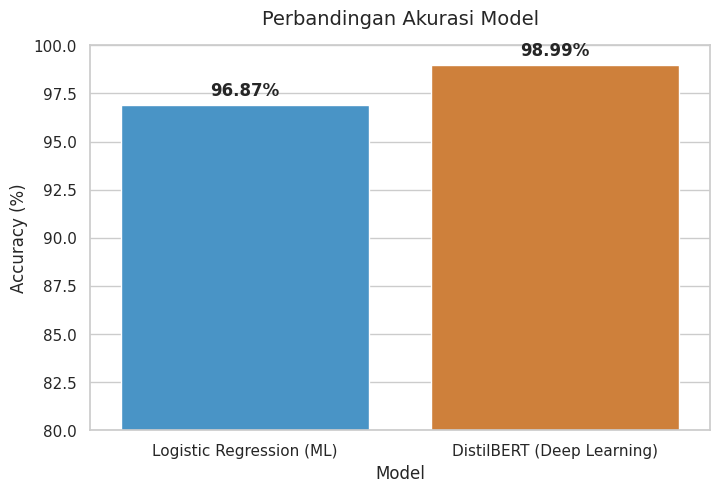

In [ ]:
metrics_df = pd.DataFrame({
    'Model': ['Logistic Regression (ML)', 'DistilBERT (Deep Learning)'],
    'Accuracy (%)': [lr_acc * 100, dl_acc * 100],
    'F1-Score (%)': [lr_f1 * 100, dl_f1 * 100],
    'Training Time (Detik)': [lr_time, dl_time]
})

print("=== Perbandingan Metrik ===")
print(metrics_df.to_string(index=False))

# Plot Perbandingan Akurasi
plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_df, x='Model', y='Accuracy (%)', palette=['#3498db', '#e67e22'])
plt.ylim(80, 100)
plt.title('Perbandingan Akurasi Model', fontsize=14, pad=15)
for i, row in metrics_df.iterrows():
    plt.text(i, row['Accuracy (%)'] + 0.5, f"{row['Accuracy (%)']:.2f}%", ha='center', fontweight='bold')
plt.show()

## 7. Sistem Deteksi Kehalalan Komposisi (Inference System)

Fungsi di bawah ini memungkinkan Anda menguji bahan/komposisi baru secara langsung dengan kedua model yang sudah dilatih untuk mendeteksi apakah bahan tersebut **HALAL** atau **HARAM** beserta nilai tingkat kepercayaannya (*confidence score*).

In [ ]:
def deteksi_kehalalan(teks_komposisi):
    teks_clean = teks_komposisi.lower().strip()

    # ================= ML PREDICTION =================
    tfidf_vec = vectorizer.transform([teks_clean])
    ml_probs = lr_model.predict_proba(tfidf_vec)[0]
    ml_pred = lr_model.predict(tfidf_vec)[0]
    ml_label = 'HALAL' if ml_pred == 0 else 'HARAM'
    ml_conf = ml_probs[ml_pred] * 100

    # ================= DL PREDICTION =================
    # Tokenisasi
    inputs = tokenizer(teks_clean, return_tensors='pt', padding=True, truncation=True, max_length=128)
    # Pindahkan ke GPU jika ada
    device_eval = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device_eval)
    inputs = {k: v.to(device_eval) for k, v in inputs.items()}

    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        dl_probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
        dl_pred = np.argmax(dl_probs)
        dl_label = 'HALAL' if dl_pred == 0 else 'HARAM'
        dl_conf = dl_probs[dl_pred] * 100

    # ================= TAMPILKAN HASIL =================
    print(f"📝 BAHAN MAKANAN / KOMPOSISI:")
    print(f"   \"{teks_komposisi}\"")
    print("=" * 60)

    # Cetak hasil Machine Learning
    color_ml = "\033[92m" if ml_label == 'HALAL' else "\033[91m"
    print(f"🤖 Prediksi Machine Learning (Logistic Regression):")
    print(f"   > Keputusan : {color_ml}{ml_label}\033[0m")
    print(f"   > Kepercayaan: {ml_conf:.2f}%")
    print("-" * 60)

    # Cetak hasil Deep Learning
    color_dl = "\033[92m" if dl_label == 'HALAL' else "\033[91m"
    print(f"🧠 Prediksi Deep Learning (DistilBERT):")
    print(f"   > Keputusan : {color_dl}{dl_label}\033[0m")
    print(f"   > Kepercayaan: {dl_conf:.2f}%")
    print("=" * 60)
    print("\n")

### Uji Coba Langsung (Live Testing)

In [ ]:
# Uji coba 1: Bahan yang jelas Halal
deteksi_kehalalan("organic brown rice, water, sea salt, organic carrots")

# Uji coba 2: Bahan yang jelas Haram karena mengandung pork (babi)
deteksi_kehalalan("wheat flour, pork fat, sugar, salt, artificial flavor")

# Uji coba 3: Kasus yang lebih samar (mengandung bumbu/kaldu ayam non-halal atau bahan hewani lainnya)
deteksi_kehalalan("water, beef stock, potato, whey milk, chicken fat, wine vinegar, sodium nitrite")

📝 BAHAN MAKANAN / KOMPOSISI:
   "organic brown rice, water, sea salt, organic carrots"
🤖 Prediksi Machine Learning (Logistic Regression):
   > Keputusan : HALAL
   > Kepercayaan: 87.25%
------------------------------------------------------------
🧠 Prediksi Deep Learning (DistilBERT):
   > Keputusan : HALAL
   > Kepercayaan: 99.81%


📝 BAHAN MAKANAN / KOMPOSISI:
   "wheat flour, pork fat, sugar, salt, artificial flavor"
🤖 Prediksi Machine Learning (Logistic Regression):
   > Keputusan : HARAM
   > Kepercayaan: 95.46%
------------------------------------------------------------
🧠 Prediksi Deep Learning (DistilBERT):
   > Keputusan : HARAM
   > Kepercayaan: 99.94%


📝 BAHAN MAKANAN / KOMPOSISI:
   "water, beef stock, potato, whey milk, chicken fat, wine vinegar, sodium nitrite"
🤖 Prediksi Machine Learning (Logistic Regression):
   > Keputusan : HARAM
   > Kepercayaan: 72.64%
------------------------------------------------------------
🧠 Prediksi Deep Learning (DistilBERT):
   > Keputusan

## 8. Cara Menyimpan Model untuk Deployment

Jika Anda ingin menggunakan model ini di website/aplikasi mobile (misalnya menggunakan Flask/FastAPI/Streamlit), Anda bisa menyimpannya dengan kode di bawah ini.

In [ ]:
import joblib

# Simpan model Logistic Regression & Vectorizer
joblib.dump(lr_model, 'model_logistic_regression.joblib')
joblib.dump(vectorizer, 'tfidf_vectorizer.joblib')
print("Model Logistic Regression & Vectorizer berhasil disimpan!")

# Simpan model DistilBERT dan Tokenizer-nya
model.save_pretrained('./best_distilbert_model')
tokenizer.save_pretrained('./best_distilbert_model')
print("Model DistilBERT & Tokenizer berhasil disimpan!")

Model Logistic Regression & Vectorizer berhasil disimpan!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model DistilBERT & Tokenizer berhasil disimpan!
